<a href="https://colab.research.google.com/github/raj143sujay/EXCELR-ASSIGNMENTS/blob/main/ASSIGNMENT_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
print(os.listdir('/content/'))

['.config', 'Decision Tree.docx', 'heart_disease.xlsx', 'sample_data']


In [ ]:
import pandas as pd
df = pd.read_excel('/content/heart_disease.xlsx')


In [ ]:
display(df.head())


,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [3]:
9import pandas as pd
df = pd.read_excel('/content/heart_disease.xlsx')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df)

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

pd.set_option('future.no_silent_downcasting', True)

# ==========================================
# 1. DATA PREPARATION & EDA
# ==========================================
print("="*60)
print("STEPS 1 & 2: DATA PREPROCESSING & EXPLORATORY ANALYSIS")
print("="*60)

# Load raw heart disease observations dataset
df_heart = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

# Handle syntax inconsistencies within the exercise target attribute 'exang'
# Fix structural text duplicates (e.g., 'TURE' vs 'True') by standardizing to binary fields
df_heart['exang'] = df_heart['exang'].astype(str).str.upper().str.strip()
df_heart['exang'] = df_heart['exang'].replace({'TRUE': 1, 'TURE': 1, 'FALSE': 0}).astype(int)

# Impute 'oldpeak' missing values using the median value parameter
print(f"Missing elements identified in 'oldpeak': {df_heart['oldpeak'].isnull().sum()} records")
df_heart['oldpeak'] = df_heart['oldpeak'].fillna(df_heart['oldpeak'].median())

# Formulate the target attribute framework: Convert multi-stage 'num' into binary format
# (0 = No Heart Disease, 1 = Presence of Heart Disease [Stages 1,2,3,4])
df_heart['target'] = (df_heart['num'] > 0).astype(int)

# Check target balance
print("\nTarget Class Distribution Matrix:")
print(df_heart['target'].value_counts())

# Generate and save numerical feature correlation structures
plt.figure(figsize=(8, 6))
numeric_cols = df_heart.select_dtypes(include=[np.number]).columns
sns.heatmap(df_heart[numeric_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Heart Disease Numeric Correlations Heatmap')
plt.tight_layout()
plt.savefig('heart_correlation_matrix.png')
plt.close()
print("\n[EDA Visualization saved as 'heart_correlation_matrix.png']")

# ==========================================
# 2. FEATURE ENGINEERING (ENCODING)
# ==========================================
# Dummy-encode categorical columns using One-Hot encoding to preserve information distance boundaries
categorical_features = ['sex', 'cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df_heart.drop(columns=['num', 'target']), columns=categorical_features, drop_first=True)

X = df_encoded.astype(float)
y = df_heart['target']

# Split dataset into 80% Training and 20% Testing with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. BASELINE VS. TUNED TREE CLASSIFICATION
# ==========================================
print("\n" + "="*60)
print("STEPS 4 & 5: MODEL TRAINING & HYPERPARAMETER TUNING")
print("="*60)

# Train an unconstrained baseline model configuration
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)
y_pred_base = baseline_tree.predict(X_test)

# Optimize hyperparameters using an exhaustive 5-fold GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 15]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Optimal Hyperparameter Constraints Identified:\n {grid_search.best_params_}")

# ==========================================
# 4. FINAL EVALUATION & METRICS METADATA
# ==========================================
print("\n" + "="*60)
print("STEP 6: TESTING EVALUATION PERFORMANCE ANALYSIS")
print("="*60)

best_tree = grid_search.best_estimator_
y_pred_best = best_tree.predict(X_test)
y_pred_proba = best_tree.predict_proba(X_test)[:, 1]

print("\n--- Model Performance Metrics Comparison ---")
print(f"Baseline Tree Accuracy : {accuracy_score(y_test, y_pred_base):.4f} | Tuned Tree Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree Precision   : {precision_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree Recall      : {recall_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree F1-Score    : {f1_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree ROC-AUC     : {roc_auc_score(y_test, y_pred_proba):.4f}")

# Extract global feature importance rules
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Most Instructive Features Identified ---")
print(importance_df.head(5).to_string(index=False))

# Visualize decision tree structure logic
print("\n--- Root Splitting Logic Rules Architecture ---")
tree_rules_text = export_text(best_tree, feature_names=list(X.columns), max_depth=2)
print(tree_rules_text)

STEPS 1 & 2: DATA PREPROCESSING & EXPLORATORY ANALYSIS
Missing elements identified in 'oldpeak': 62 records

Target Class Distribution Matrix:
target
1    509
0    399
Name: count, dtype: int64

[EDA Visualization saved as 'heart_correlation_matrix.png']

STEPS 4 & 5: MODEL TRAINING & HYPERPARAMETER TUNING
Optimal Hyperparameter Constraints Identified:
 {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 15, 'min_samples_split': 2}

STEP 6: TESTING EVALUATION PERFORMANCE ANALYSIS

--- Model Performance Metrics Comparison ---
Baseline Tree Accuracy : 0.7033 | Tuned Tree Accuracy : 0.7637
Tuned Tree Precision   : 0.7757
Tuned Tree Recall      : 0.8137
Tuned Tree F1-Score    : 0.7943
Tuned Tree ROC-AUC     : 0.8036

--- Top 5 Most Instructive Features Identified ---
Feature  Importance
  exang    0.411325
   chol    0.206589
 thalch    0.109504
    age    0.080130
oldpeak    0.060115

--- Root Splitting Logic Rules Architecture ---
|--- exang <= 0.50
|   |--- chol <= 42.50
|   | 

In [ ]:
import joblib

# Save the tuned decision tree model to a file
joblib.dump(best_tree, 'tuned_decision_tree_model.joblib')

print("Tuned Decision Tree Model exported as 'tuned_decision_tree_model.joblib'")

Tuned Decision Tree Model exported as 'tuned_decision_tree_model.joblib'


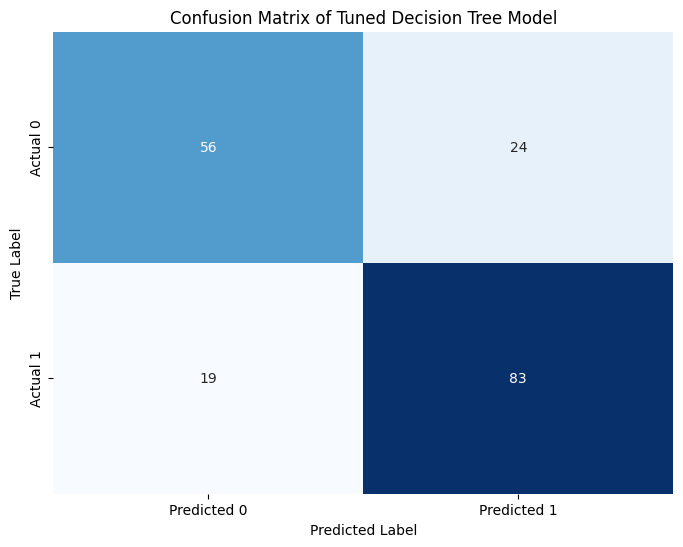

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix of Tuned Decision Tree Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelEvaluation'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# =====================================================================
# 1. DATA PREPARATION & EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
print("="*65)
print("STEPS 1 & 2: DATA PREPROCESSING & EXPLORATORY DATA ANALYSIS")
print("="*65)

# Load the raw heart disease observations dataset
df_heart = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

# Handle syntax inconsistencies within the exercise target attribute 'exang'
# Fix structural text duplicates (e.g., 'TURE' vs 'True') by standardizing to uniform integer fields
df_heart['exang'] = df_heart['exang'].astype(str).str.upper().str.strip()
df_heart['exang'] = df_heart['exang'].replace({'TRUE': 1, 'TURE': 1, 'FALSE': 0})

# Impute 'oldpeak' missing values using the column's median value parameter
print(f"Missing elements identified in 'oldpeak': {df_heart['oldpeak'].isnull().sum()} records")
df_heart['oldpeak'] = df_heart['oldpeak'].fillna(df_heart['oldpeak'].median())

# Formulate the target attribute framework: Convert multi-stage 'num' into binary format
# (0 = No Heart Disease, 1 = Presence of Heart Disease [Stages 1, 2, 3, 4])
df_heart['target'] = (df_heart['num'] > 0).astype(int)

# Check target balance
print("\nTarget Class Distribution Matrix:")
print(df_heart['target'].value_counts())

# Generate and save numerical feature correlation structures
plt.figure(figsize=(8, 6))
numeric_cols = df_heart.select_dtypes(include=[np.number]).columns
sns.heatmap(df_heart[numeric_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Heart Disease Numeric Correlations Heatmap')
plt.tight_layout()
plt.savefig('heart_correlation_matrix.png')
plt.close()
print("\n[EDA Correlation Heatmap saved successfully as 'heart_correlation_matrix.png']")

# =====================================================================
# 2. FEATURE ENGINEERING (CATEGORICAL ENCODING)
# =====================================================================
# One-hot encode string categorical features to preserve unranked distance boundaries
categorical_features = ['sex', 'cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df_heart.drop(columns=['num', 'target']), columns=categorical_features, drop_first=True)

X = df_encoded.astype(float)
y = df_heart['target']

# Split dataset into 80% Training and 20% Testing with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =====================================================================
# 3. DECISION TREE CLASSIFICATION & HYPERPARAMETER TUNING
# =====================================================================
print("\n" + "="*65)
print("STEPS 4 & 5: MODEL TRAINING & HYPERPARAMETER TUNING")
print("="*65)

# Train an unconstrained baseline model configuration
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)
y_pred_base = baseline_tree.predict(X_test)

# Optimize hyperparameters using an exhaustive 5-fold GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 15]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Optimal Hyperparameter Constraints Identified:\n {grid_search.best_params_}")

# =====================================================================
# 4. FINAL EVALUATION & DECISION TREE STRUCTURAL ANALYSIS
# =====================================================================
print("\n" + "="*65)
print("STEP 6: TESTING EVALUATION PERFORMANCE ANALYSIS")
print("="*65)

best_tree = grid_search.best_estimator_
y_pred_best = best_tree.predict(X_test)
y_pred_proba = best_tree.predict_proba(X_test)[:, 1]

print("\n--- Model Performance Metrics Comparison ---")
print(f"Baseline Tree Accuracy : {accuracy_score(y_test, y_pred_base):.4f} | Tuned Tree Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree Precision   : {precision_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree Recall      : {recall_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree F1-Score    : {f1_score(y_test, y_pred_best):.4f}")
print(f"Tuned Tree ROC-AUC     : {roc_auc_score(y_test, y_pred_proba):.4f}")

# Extract global feature importance scores
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Most Instructive Features Identified ---")
print(importance_df.head(5).to_string(index=False))

# Visualize the decision tree's root splitting rules textually
print("\n--- Decision Tree Root Split Structure Logic ---")
tree_rules_text = export_text(best_tree, feature_names=list(X.columns), max_depth=2)
print(tree_rules_text)

STEPS 1 & 2: DATA PREPROCESSING & EXPLORATORY DATA ANALYSIS
Missing elements identified in 'oldpeak': 62 records

Target Class Distribution Matrix:
target
1    509
0    399
Name: count, dtype: int64

[EDA Correlation Heatmap saved successfully as 'heart_correlation_matrix.png']

STEPS 4 & 5: MODEL TRAINING & HYPERPARAMETER TUNING
Optimal Hyperparameter Constraints Identified:
 {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 15, 'min_samples_split': 2}

STEP 6: TESTING EVALUATION PERFORMANCE ANALYSIS

--- Model Performance Metrics Comparison ---
Baseline Tree Accuracy : 0.7033 | Tuned Tree Accuracy : 0.7637
Tuned Tree Precision   : 0.7757
Tuned Tree Recall      : 0.8137
Tuned Tree F1-Score    : 0.7943
Tuned Tree ROC-AUC     : 0.8036

--- Top 5 Most Instructive Features Identified ---
Feature  Importance
  exang    0.411325
   chol    0.206589
 thalch    0.109504
    age    0.080130
oldpeak    0.060115

--- Decision Tree Root Split Structure Logic ---
|--- exang <= 0.50
|   

### Distribution of Numerical Features (Histograms)

In [6]:
# Re-load df_heart and define numerical_cols for visualization cells
# This ensures df_heart is available for subsequent plotting, independent of prior cell execution state.
import pandas as pd
pd.set_option('future.no_silent_downcasting', True) # Set option to handle FutureWarning
df_heart = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

# Re-process 'exang' as done in the main preprocessing cell
df_heart['exang'] = df_heart['exang'].astype(str).str.upper().str.strip()
df_heart['exang'] = df_heart['exang'].replace({'TRUE': 1, 'TURE': 1, 'FALSE': 0})

# Impute 'oldpeak' missing values
df_heart['oldpeak'] = df_heart['oldpeak'].fillna(df_heart['oldpeak'].median())

# Define target
df_heart['target'] = (df_heart['num'] > 0).astype(int)

numerical_cols = df_heart.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude 'num' and 'target' as they are processed separately or are target variables
if 'num' in numerical_cols:
    numerical_cols.remove('num')
if 'target' in numerical_cols:
    numerical_cols.remove('target')
print("df_heart and numerical_cols have been re-initialized.")

df_heart and numerical_cols have been re-initialized.


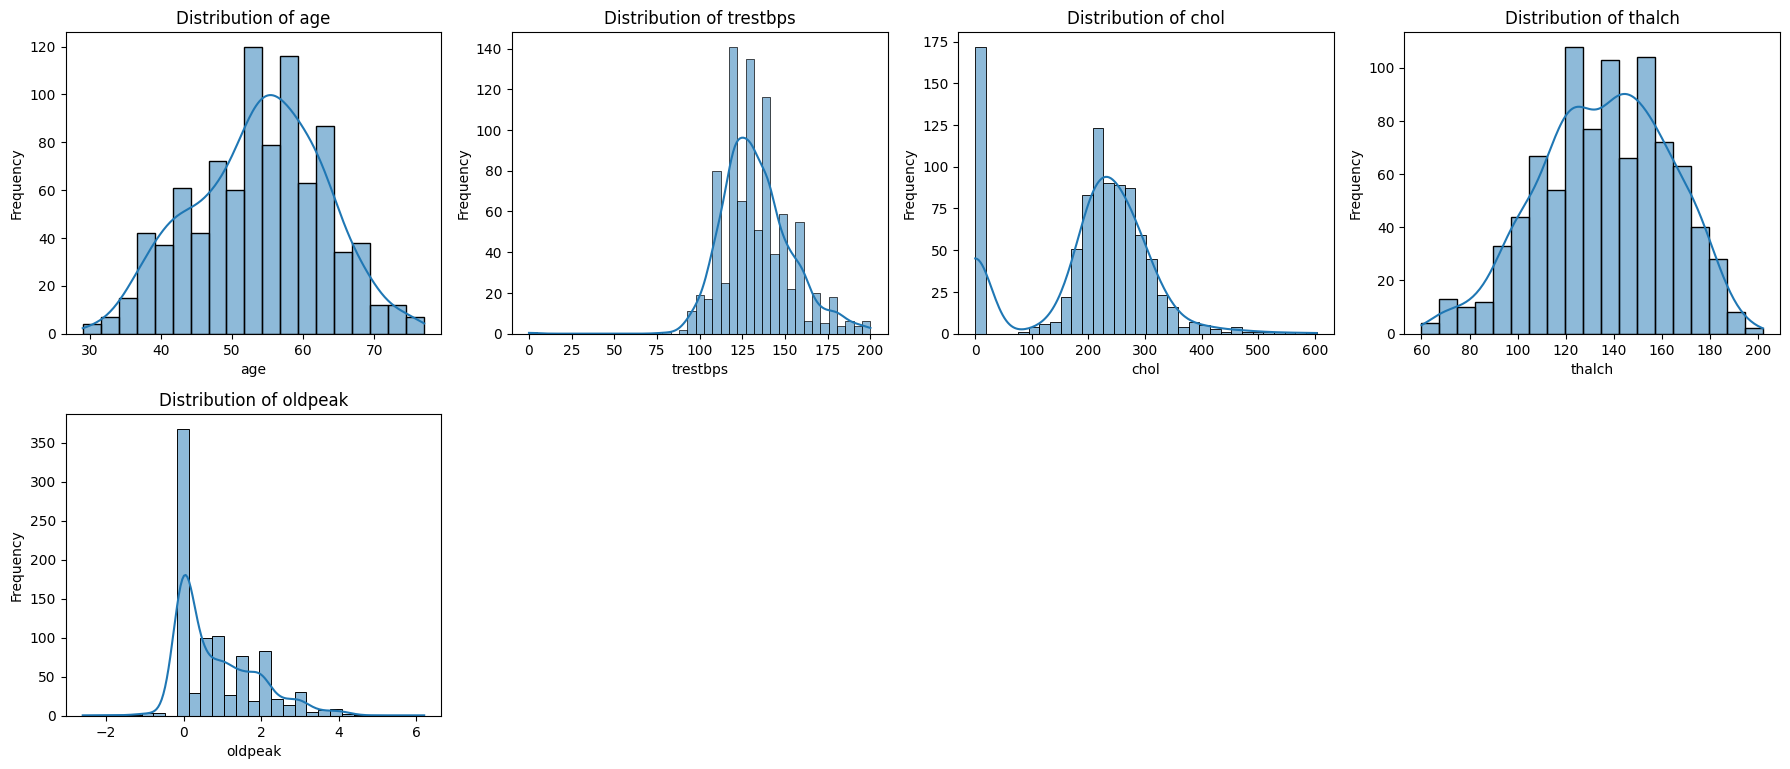

Numerical feature histograms saved as 'numerical_feature_histograms.png'


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# Identify numerical columns for histograms and box plots
# Ensure 'df_heart' is defined by running previous data preprocessing cells (e.g., cell 1rEpUbsIMcUy or 4414ee6f)
# To prevent NameError, if df_heart is not globally available, uncomment and run the following lines:
# import pandas as pd
# pd.set_option('future.no_silent_downcasting', True)
# df_heart = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')
# df_heart['exang'] = df_heart['exang'].astype(str).str.upper().str.strip()
# df_heart['exang'] = df_heart['exang'].replace({'TRUE': 1, 'TURE': 1, 'FALSE': 0})
# df_heart['oldpeak'] = df_heart['oldpeak'].fillna(df_heart['oldpeak'].median())
# df_heart['target'] = (df_heart['num'] > 0).astype(int)

numerical_cols = df_heart.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude 'num' and 'target' as they are processed separately or are target variables
if 'num' in numerical_cols:
    numerical_cols.remove('num')
if 'target' in numerical_cols:
    numerical_cols.remove('target')

# Plot histograms for numerical features
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_heart[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('numerical_feature_histograms.png')
plt.show()
print("Numerical feature histograms saved as 'numerical_feature_histograms.png'")

### Outlier Identification (Box Plots)

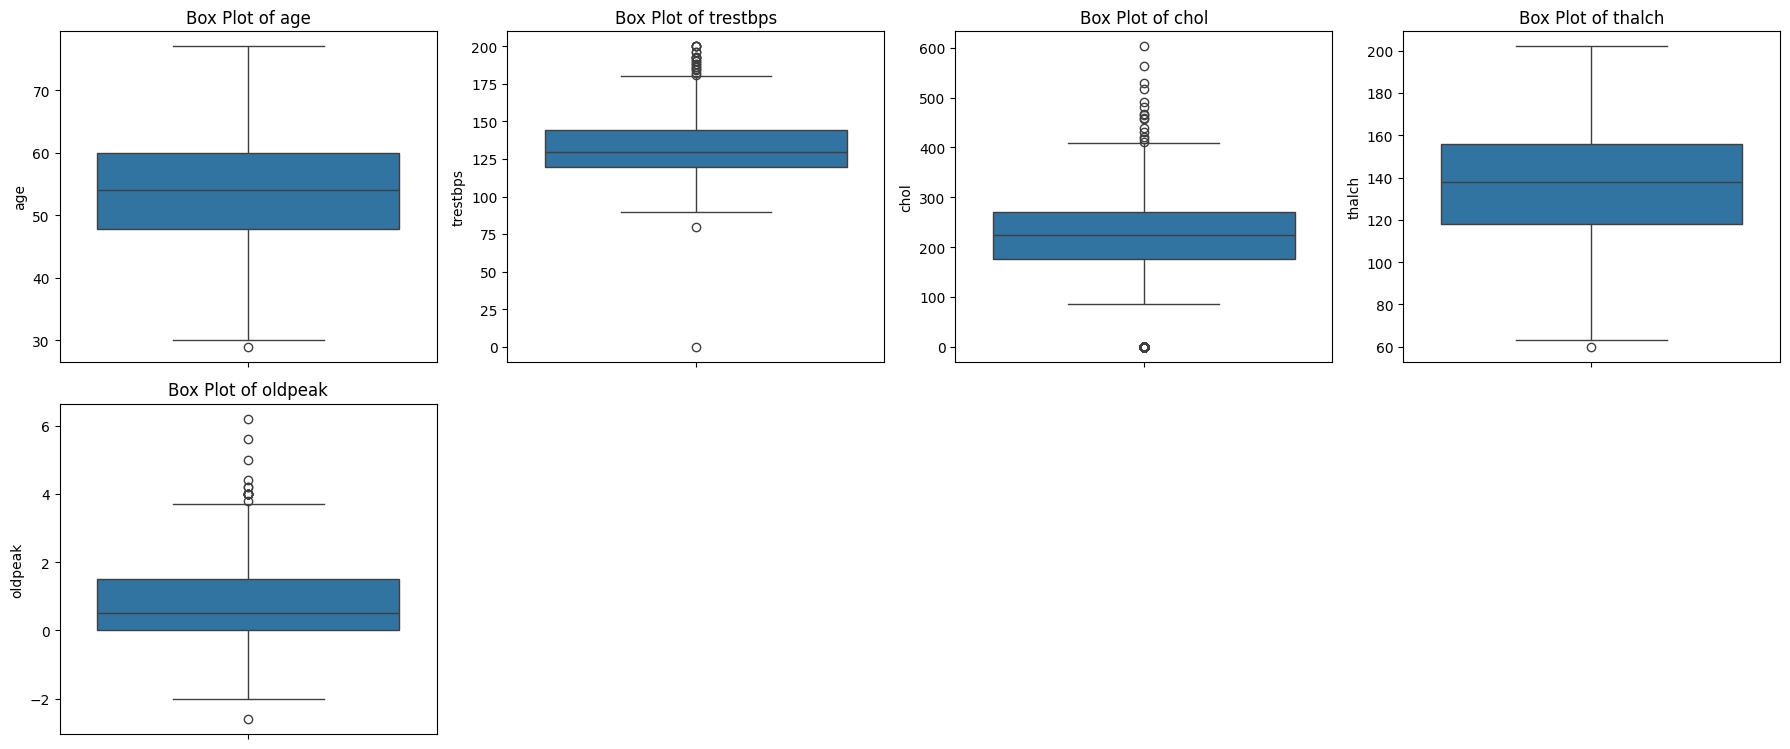

Numerical feature box plots saved as 'numerical_feature_boxplots.png'


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot box plots for numerical features to identify outliers
# Ensure 'df_heart' and 'numerical_cols' are defined by running the re-initialization cell (4414ee6f)
# and then the histogram cell (4f44530e) before running this cell.
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df_heart[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.savefig('numerical_feature_boxplots.png')
plt.show()
print("Numerical feature box plots saved as 'numerical_feature_boxplots.png'")

In [8]:
pip install graphviz

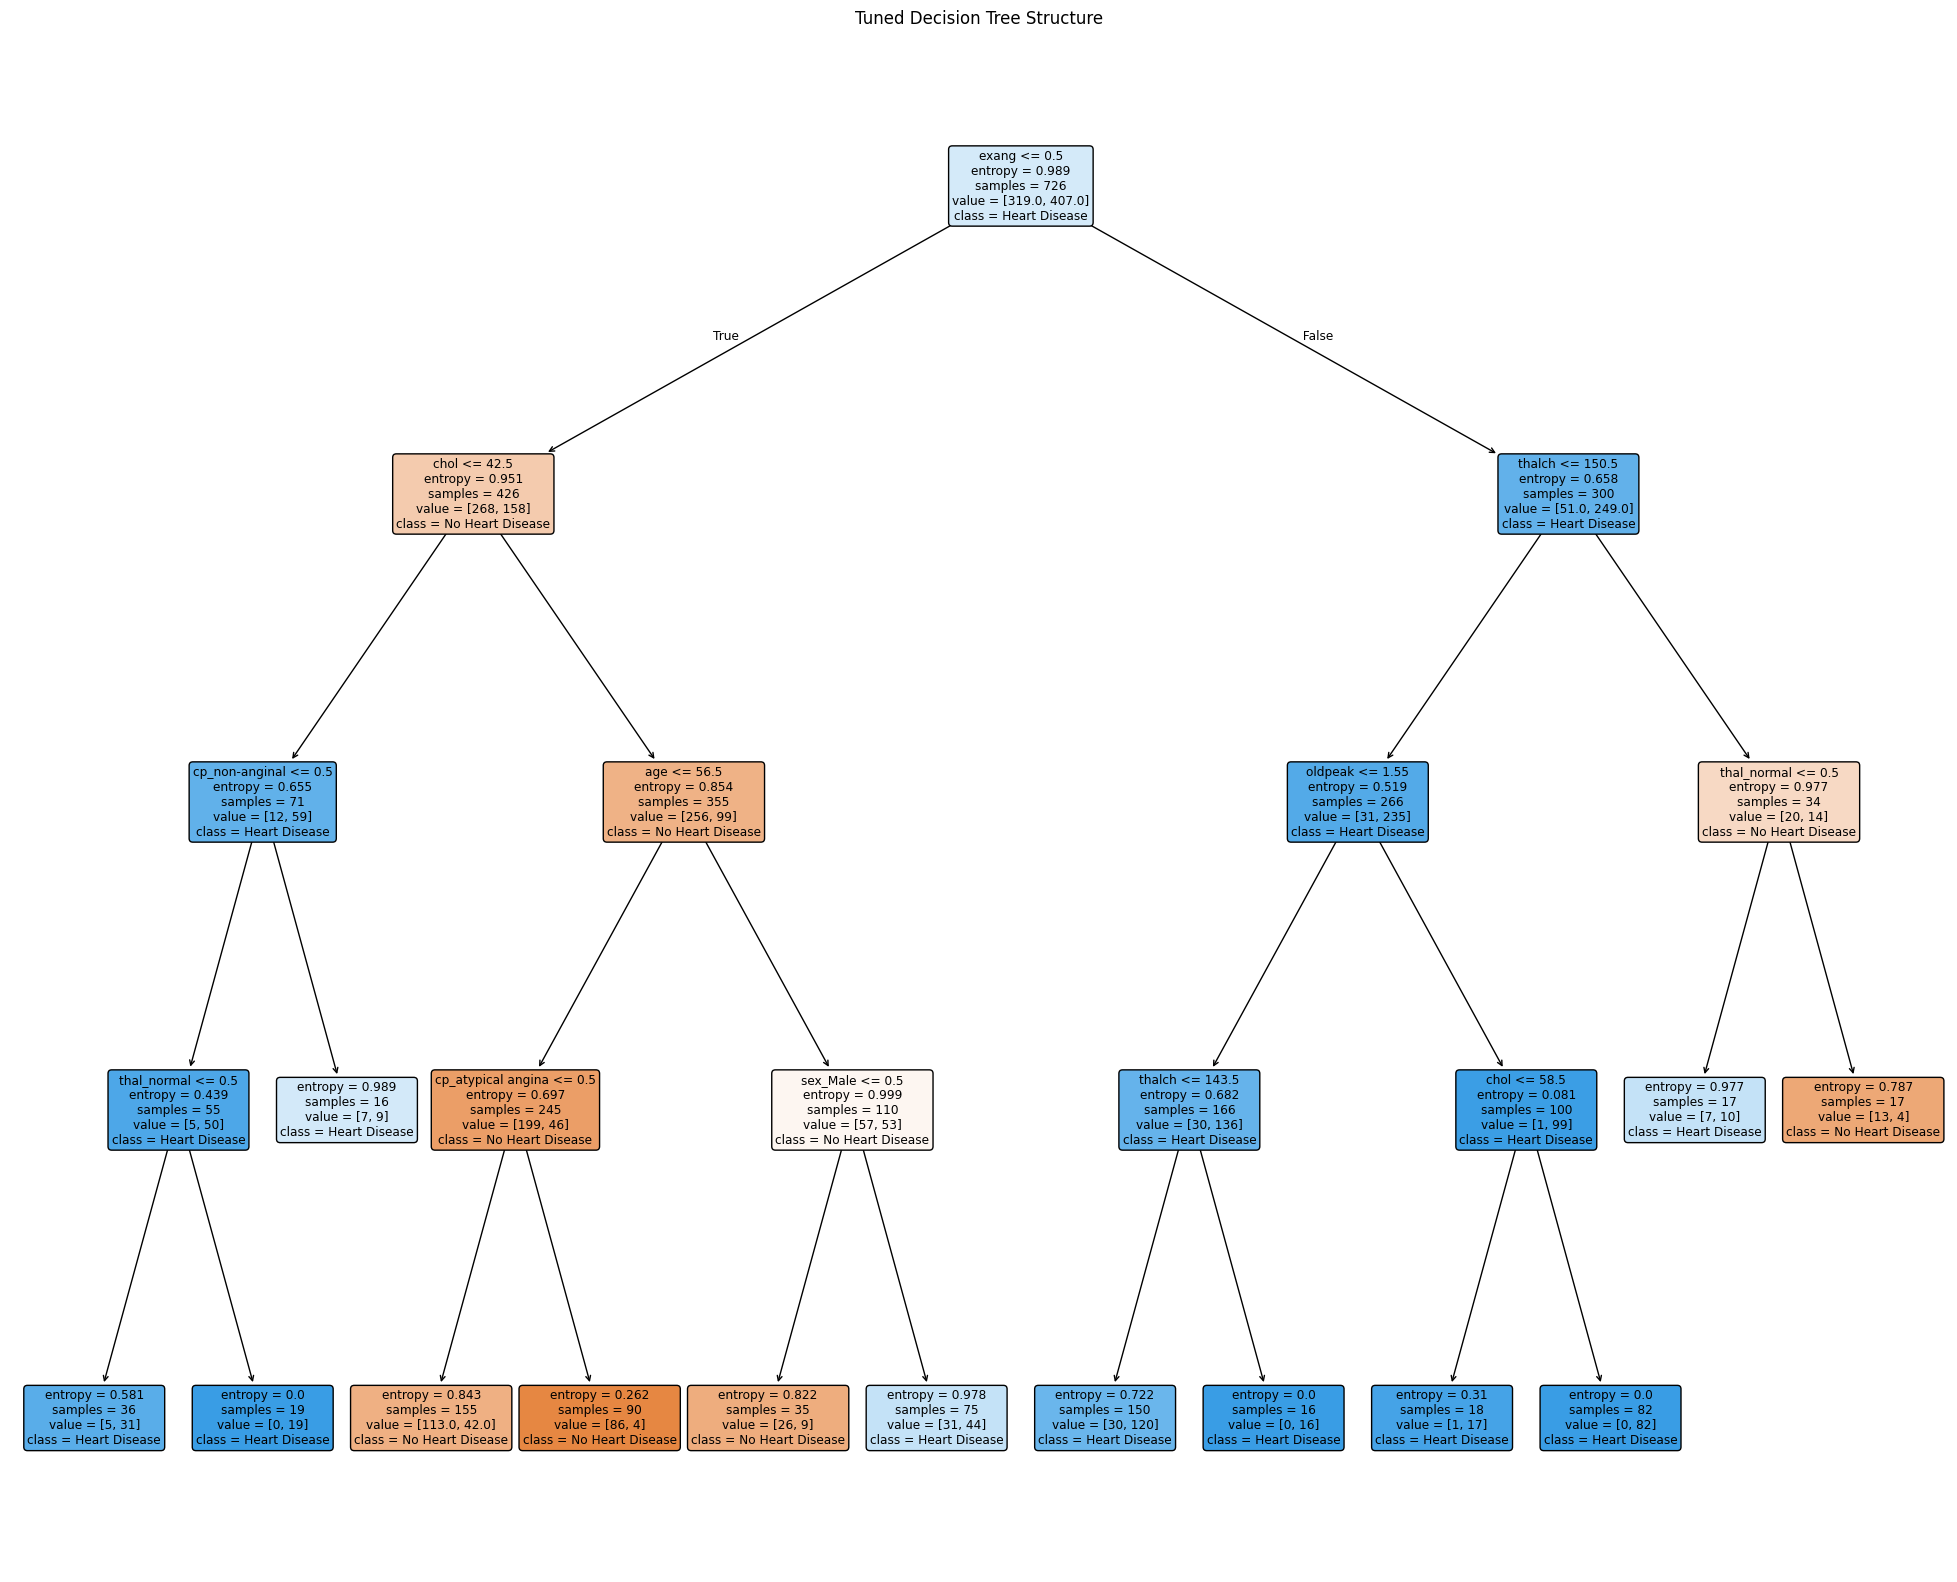

Tuned Decision Tree Visualization saved as 'tuned_decision_tree_visualization.png'


In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 20))
plot_tree(best_tree, filled=True, feature_names=X.columns.tolist(), class_names=['No Heart Disease', 'Heart Disease'], rounded=True)
plt.title('Tuned Decision Tree Structure')
plt.savefig('tuned_decision_tree_visualization.png')
plt.show()
print("Tuned Decision Tree Visualization saved as 'tuned_decision_tree_visualization.png'")

### Cross-Validation of Tuned Decision Tree

In [10]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the tuned Decision Tree model
cv_scores = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores: [0.78767123 0.8        0.82068966 0.74482759 0.74482759]
Mean cross-validation accuracy: 0.7796
Standard deviation of cross-validation accuracy: 0.0303


### Feature Importance Rankings

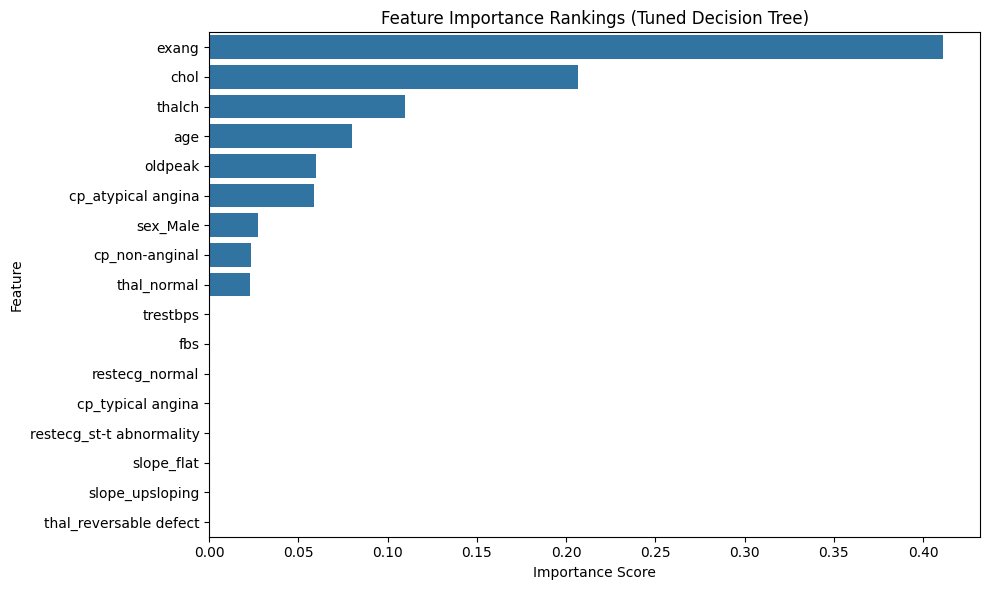

Feature importance ranking visualization saved as 'feature_importance_ranking.png'


In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance Rankings (Tuned Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_ranking.png')
plt.show()
print("Feature importance ranking visualization saved as 'feature_importance_ranking.png'")

In [1]:
pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.5 MB/s eta 0:00:00


In [4]:
from docx import Document

def read_docx(file_path):
    doc = Document(file_path)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

docx_content = read_docx('/content/Decision Tree.docx')
print("Content of Decision Tree.docx:\n")
print(docx_content)

Content of Decision Tree.docx:

1Decision Tree
Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.
Tasks:
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).
2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.
3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.
4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scik

Interview Questions:

What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

criterion: This defines the function to measure the quality of a split. Common choices are 'gini' for Gini impurity and 'entropy' for information gain. 'Gini' is generally faster to compute, while 'entropy' might lead to slightly more balanced trees. The choice can influence the purity of the nodes and the overall structure of the tree.
max_depth: This is the maximum depth of the tree. A deeper tree can capture more complex relationships but is prone to overfitting. A shallower tree is simpler but might underfit the data. Tuning max_depth helps in finding a balance between bias and variance.
min_samples_split: The minimum number of samples required to split an internal node. Increasing this value prevents the tree from learning relationships that are too specific to the training data, thereby reducing overfitting. If min_samples_split is too high, the model might underfit.
min_samples_leaf: The minimum number of samples required to be at a leaf node. Similar to min_samples_split, this parameter helps control overfitting by ensuring that each leaf node has a sufficient number of samples, preventing the creation of leaf nodes based on very few observations.
max_features: The number of features to consider when looking for the best split. This can be an integer, a float (percentage), or specific strategies like 'sqrt' or 'log2'. Restricting the number of features considered at each split can help reduce variance and make the model more robust.
What is the difference between Label encoding and One-hot encoding?

Label Encoding: This method assigns a unique integer (label) to each category in a categorical feature. For example, if you have 'Red', 'Green', 'Blue', they might be encoded as 0, 1, 2. It's simple and space-efficient, but it introduces an artificial ordinal relationship between categories. This means the model might incorrectly infer that 'Green' (1) is somehow 'greater' than 'Red' (0) or 'less' than 'Blue' (2), which is problematic for nominal categories (categories without an inherent order).
One-Hot Encoding: This method creates new binary columns for each category in a categorical feature. For each original category, a new column is added, and a '1' is placed in that column for the corresponding row, with '0's in all other new category columns. Using the 'Red', 'Green', 'Blue' example, 'Red' would become [1, 0, 0], 'Green' [0, 1, 0], and 'Blue' [0, 0, 1]. This avoids the artificial ordinal relationship problem of label encoding and is suitable for nominal categorical variables. However, it can lead to a significant increase in the dimensionality of the dataset, especially with many categories, which can impact performance and increase computational cost.

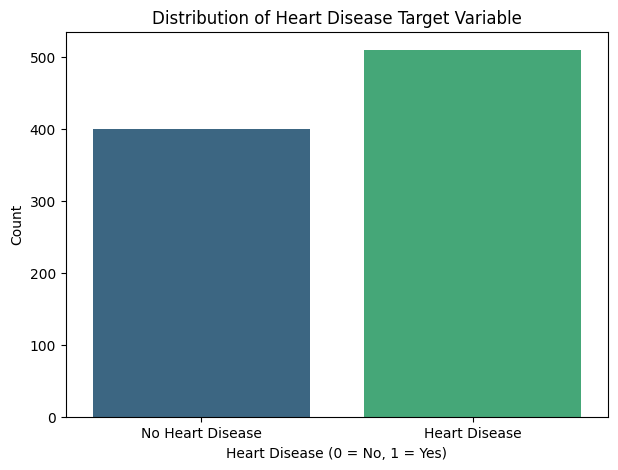

Target variable distribution plot displayed.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Add pandas import

# Re-load df_heart and define target variable
pd.set_option('future.no_silent_downcasting', True)
df_heart = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

# Re-process 'exang'
df_heart['exang'] = df_heart['exang'].astype(str).str.upper().str.strip()
df_heart['exang'] = df_heart['exang'].replace({'TRUE': 1, 'TURE': 1, 'FALSE': 0})

# Impute 'oldpeak' missing values
df_heart['oldpeak'] = df_heart['oldpeak'].fillna(df_heart['oldpeak'].median())

# Define target
df_heart['target'] = (df_heart['num'] > 0).astype(int)

plt.figure(figsize=(7, 5))
sns.countplot(x='target', data=df_heart, palette='viridis', hue='target', legend=False)
plt.title('Distribution of Heart Disease Target Variable')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
plt.show()
print("Target variable distribution plot displayed.")

Here are the comprehensive answers to the interview questions specified in your **Decision Tree Classification Assignment** document.

---

## Interview Question 1: What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Hyperparameters are constraints applied to a decision tree before training to control its growth, architecture, and complexity. Because unconstrained decision trees will continue splitting until every training sample is perfectly isolated, adjusting these parameters is vital to prevent **overfitting**.

The most common hyperparameters in libraries like `scikit-learn` include:

### 1. Maximum Depth (`max_depth`)

* **What it is:** The maximum number of levels (vertical splits) from the root node down to the deepest leaf node.
* **Effect on Performance:** * **Too High:** The tree becomes highly complex, creating specific rules that memorize random noise and outliers in the training set (**overfitting**). This leads to excellent training accuracy but poor generalization on test data.
* **Too Low:** The tree is cut off before it can capture meaningful, non-linear patterns in the features (**underfitting**).



### 2. Minimum Samples Split (`min_samples_split`)

* **What it is:** The minimum number of data samples that must be present in an internal node before it is allowed to be split into sub-nodes.
* **Effect on Performance:** * Higher values prevent the model from creating highly specific branches tailored to small, unrepresentative subsets of your data, acting as a strong regularizer. If set too high, however, the tree may stop splitting prematurely, leading to underfitting.

### 3. Minimum Samples Leaf (`min_samples_leaf`)

* **What it is:** The minimum number of data samples required to be present at a terminal leaf node.
* **Effect on Performance:** * This parameter smooths the model. A split will only be made if both the left and right resulting branches contain at least the specified number of samples. Higher values prevent the model from creating leaf nodes based on highly isolated exceptional cases or a single outlier.

### 4. Splitting Criterion (`criterion`)

* **What it is:** The mathematical function used to measure the quality of a feature split at each node. Common options are **Gini Impurity** (`'gini'`) and **Information Gain/Entropy** (`'entropy'`).
* **Effect on Performance:** * **Gini Impurity** focuses on minimizing misclassification. It computes much faster because it does not require calculating logarithmic scales.
* **Entropy** measures the disorder or randomness of information in a node. It is more computationally expensive due to the use of logarithms ($\log_2$), but it often builds slightly more balanced tree structures by searching for highly pure class distributions.



---

## Interview Question 2: What is the difference between Label encoding and One-hot encoding?

Both techniques are used to convert categorical string values into numerical formats that machine learning models can understand, but they make very different mathematical assumptions about the underlying data:

### Detailed Comparison Table

| Comparison Metric | Label Encoding | One-Hot Encoding |
| --- | --- | --- |
| **Operational Execution** | Converts each unique category string into a sequential integer value ($0, 1, 2, 3\dots$) within a single column. | Spreads the categories across entirely new, distinct columns ($0$ or $1$) for each unique category value. |
| **Mathematical Assumption** | **Introduces a false mathematical ranking.** The model may incorrectly assume that category `3` is inherently superior to or greater than category `0`. | **Maintains absolute rank equality.** Each category is treated as an independent binary choice with zero implied ordering or distance bias. |
| **Dimensionality Impact** | Keeps the dataset compact. The shape of the feature matrix remains unchanged because it modifies the column in place. | **Increases dataset width.** If a column has high cardinality (many unique values), it can significantly increase the number of columns, causing data sparsity. |
| **Best Used For...** | **Ordinal variables** where a natural, logical sequence or rank exists (e.g., `Education Stage`: `High School=0, Bachelors=1, PhD=2`). | **Nominal variables** where categories have no inherent relationship, order, or ranking (e.g., `Chest Pain Type`: `typical, atypical, non-anginal`). |

### Impact Specific to Decision Trees

Decision trees split data sequentially based on thresholds (e.g., $\text{Feature} \leq 1.5$).

* When using **Label Encoding** on a nominal feature like color (`Red=0, Blue=1, Green=2`), a decision tree is forced to split them numerically. For instance, a split at $\leq 1.5$ groups `Red` and `Blue` together on one side and isolates `Green` on the other.
* While decision trees can eventually work around this by making multiple sequential splits down the line, **One-Hot Encoding** provides a much cleaner, more intuitive structure for trees handling nominal data. It allows the model to isolate specific categories in a single split (e.g., $\text{Is_Blue} > 0.5$).